# Graduation_Project : Grocery_Orders Analysis




## Introduction
Welcome to the Exploratory Data Analysis (EDA) notebook for the Grocery Orders project. The main goal of this analysis is to explore, clean, and understand customer purchasing patterns, order intervals, and product details across the dataset.

**Dataset Columns**

| Column | Meaning |
|---|---|
| order_id | unique ID of the order |
| User_id |  unique user ID |
| eval_set | prior - train - test     |
| order_number| the sequence number for this user: 1 = their first ever order, 2 = their second|
| order_dow|day of the week(0 = Sunday … 6 = Saturday)|
| order_hour_of_day|  hour of the day (0–23) |
| days_since_prior_order|how many days since this customer's previous order.|
| product_id| unique product ID |
| product_name|human-readable name|
| aisle|the aisle name|
| aisle_id|  unique aisle ID  |
|department_id|  unique department ID |
| department|the department name|
| add_to_cart_order|1 = first item added , 2 = second item added |
| reordered| product is a repeat purchase (1) or a first-time buy (0)|


# 0. Setup

First we import the libraries we need and do a 30-second recap of Python we will rely on:

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error



 # 1. Loading the data and Initial EDA


In this section, we will:
* Load the dataset using Pandas.
* Check the structural information and data types of the DataFrame.
* Generate descriptive statistics to understand the data distribution.

# 0.EDA: Orders.csv



In [2]:
orders_df = pd.read_csv('grocery_orders/orders.csv')
orders_df.head(10)

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0
5,3367565,1,prior,6,2,7,19.0
6,550135,1,prior,7,1,9,20.0
7,3108588,1,prior,8,1,14,14.0
8,2295261,1,prior,9,1,16,0.0
9,2550362,1,prior,10,4,8,30.0


In [3]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                str    
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), str(1)
memory usage: 182.7 MB


In [4]:
orders_df.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


# 1.EDA: Products.csv

In [5]:
products_df = pd.read_csv('grocery_orders/products.csv')
products_df.head(10)

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
5,6,Dry Nose Oil,11,11
6,7,Pure Coconut Water With Orange,98,7
7,8,Cut Russet Potatoes Steam N' Mash,116,1
8,9,Light Strawberry Blueberry Yogurt,120,16
9,10,Sparkling Orange Juice & Prickly Pear Beverage,115,7


In [6]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49688 non-null  int64
 1   product_name   49688 non-null  str  
 2   aisle_id       49688 non-null  int64
 3   department_id  49688 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [7]:
products_df.describe()

,product_id,aisle_id,department_id
count,49688.000000,49688.000000,49688.000000
mean,24844.500000,67.769582,11.728687
std,14343.834425,38.316162,5.850410
min,1.000000,1.000000,1.000000
25%,12422.750000,35.000000,7.000000
50%,24844.500000,69.000000,13.000000
75%,37266.250000,100.000000,17.000000
max,49688.000000,134.000000,21.000000


# 2.EDA: departments.csv


In [8]:
departments_df = pd.read_csv('grocery_orders/departments.csv')
departments_df.head(10)

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [9]:
departments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   department_id  21 non-null     int64
 1   department     21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 468.0 bytes


In [10]:
departments_df.describe()

,department_id
count,21.000000
mean,11.000000
std,6.204837
min,1.000000
25%,6.000000
50%,11.000000
75%,16.000000
max,21.000000


# 3.EDA: Order_products_prior.csv


In [11]:
order_products_prior_df = pd.read_csv('grocery_orders/order_products__prior.csv', nrows=500000)
order_products_prior_df.head(10)


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0
5,2,17794,6,1
6,2,40141,7,1
7,2,1819,8,1
8,2,43668,9,0
9,3,33754,1,1


In [12]:
order_products_prior_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   order_id           500000 non-null  int64
 1   product_id         500000 non-null  int64
 2   add_to_cart_order  500000 non-null  int64
 3   reordered          500000 non-null  int64
dtypes: int64(4)
memory usage: 15.3 MB


In [13]:
order_products_prior_df.describe()

,order_id,product_id,add_to_cart_order,reordered
count,500000.000000,500000.000000,500000.000000,500000.000000
mean,26400.108476,25564.192186,8.348422,0.590246
std,15262.554968,14100.724459,7.115773,0.491789
min,2.000000,1.000000,1.000000,0.000000
25%,13208.000000,13514.000000,3.000000,0.000000
50%,26350.000000,25246.000000,6.000000,1.000000
75%,39561.000000,37849.000000,11.000000,1.000000
max,52883.000000,49688.000000,92.000000,1.000000


# 4.EDA: aisles.csv


In [14]:
aisles_df = pd.read_csv('grocery_orders/aisles.csv')
aisles_df.head(10)

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation
5,6,other
6,7,packaged meat
7,8,bakery desserts
8,9,pasta sauce
9,10,kitchen supplies


In [15]:
aisles_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   aisle_id  134 non-null    int64
 1   aisle     134 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.2 KB


In [16]:
aisles_df.describe()

,aisle_id
count,134.000000
mean,67.500000
std,38.826537
min,1.000000
25%,34.250000
50%,67.500000
75%,100.750000
max,134.000000


# 5.EDA: order_products_train.csv


In [17]:
order_products_train_df = pd.read_csv('grocery_orders/order_products__train.csv')
order_products_train_df.head(10)

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1
5,1,13176,6,0
6,1,47209,7,0
7,1,22035,8,1
8,36,39612,1,0
9,36,19660,2,1


In [18]:
order_products_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           1384617 non-null  int64
 1   product_id         1384617 non-null  int64
 2   add_to_cart_order  1384617 non-null  int64
 3   reordered          1384617 non-null  int64
dtypes: int64(4)
memory usage: 42.3 MB


In [19]:
order_products_train_df.describe()

,order_id,product_id,add_to_cart_order,reordered
count,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06
mean,1.706298e+06,2.555624e+04,8.758044e+00,5.985944e-01
std,9.897326e+05,1.412127e+04,7.423936e+00,4.901829e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.433700e+05,1.338000e+04,3.000000e+00,0.000000e+00
50%,1.701880e+06,2.529800e+04,7.000000e+00,1.000000e+00
75%,2.568023e+06,3.794000e+04,1.200000e+01,1.000000e+00
max,3.421070e+06,4.968800e+04,8.000000e+01,1.000000e+00


# 2. Merging & Cleaning Datasets

In this section, we combine all the isolated datasets into a single, comprehensive DataFrame (`df_merged`) using left joins. This allows us to link customer orders with full product details, aisles, and departments for a deeper analysis.

### Merging Strategy:
* Connect prior order products with overall order details via `order_id`.
* Map product information (names, categories) using `product_id`.
* Link aisles and departments metadata using `aisle_id` and `department_id`.


In [20]:
df_merged = pd.merge(order_products_prior_df, orders_df, on ='order_id', how='left')
df_merged = pd.merge(df_merged, products_df,on='product_id',how='left')
df_merged = pd.merge(df_merged,aisles_df,on='aisle_id', how='left')
df_merged = pd.merge(df_merged,departments_df, on='department_id', how='left')
df_merged.head(20)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry
5,2,17794,6,1,202279,prior,3,5,9,8.0,Carrots,83,4,fresh vegetables,produce
6,2,40141,7,1,202279,prior,3,5,9,8.0,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry
7,2,1819,8,1,202279,prior,3,5,9,8.0,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry
8,2,43668,9,0,202279,prior,3,5,9,8.0,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce
9,3,33754,1,1,205970,prior,16,5,17,12.0,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs


# 3. Quick Exploration of the Merged Dataset

Now that we have combined the datasets, let's check the overall structure, shape, and data types of the final combined DataFrame.


In [21]:
print('Shape:', df_merged.shape)
print()
print('Columns:', list(df_merged.columns))
print()
print(df_merged.dtypes)

Shape: (500000, 15)

Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department']

order_id                    int64
product_id                  int64
add_to_cart_order           int64
reordered                   int64
user_id                     int64
eval_set                      str
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
product_name                  str
aisle_id                    int64
department_id               int64
aisle                         str
department                    str
dtype: object


In [22]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                500000 non-null  int64  
 1   product_id              500000 non-null  int64  
 2   add_to_cart_order       500000 non-null  int64  
 3   reordered               500000 non-null  int64  
 4   user_id                 500000 non-null  int64  
 5   eval_set                500000 non-null  str    
 6   order_number            500000 non-null  int64  
 7   order_dow               500000 non-null  int64  
 8   order_hour_of_day       500000 non-null  int64  
 9   days_since_prior_order  468026 non-null  float64
 10  product_name            500000 non-null  str    
 11  aisle_id                500000 non-null  int64  
 12  department_id           500000 non-null  int64  
 13  aisle                   500000 non-null  str    
 14  department              500000 

In [23]:
df_merged.describe()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,468026.000000,500000.000000,500000.000000
mean,26400.108476,25564.192186,8.348422,0.590246,103246.307530,17.266272,2.737464,13.430762,11.001669,71.207052,9.922862
std,15262.554968,14100.724459,7.115773,0.491789,59440.331665,17.707578,2.085868,4.264669,8.675150,38.206874,6.283574
min,2.000000,1.000000,1.000000,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,13208.000000,13514.000000,3.000000,0.000000,51748.000000,5.000000,1.000000,10.000000,5.000000,31.000000,4.000000
50%,26350.000000,25246.000000,6.000000,1.000000,103035.000000,11.000000,3.000000,13.000000,8.000000,83.000000,9.000000
75%,39561.000000,37849.000000,11.000000,1.000000,155185.000000,24.000000,5.000000,16.000000,15.000000,107.000000,16.000000
max,52883.000000,49688.000000,92.000000,1.000000,206208.000000,99.000000,6.000000,23.000000,30.000000,134.000000,21.000000


## 3.1 Checking for Missing Values

We will check for any missing values across all columns in our merged dataset and calculate their percentages. 


In [24]:
df_merged.isna().sum()

order_id                      0
product_id                    0
add_to_cart_order             0
reordered                     0
user_id                       0
eval_set                      0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    31974
product_name                  0
aisle_id                      0
department_id                 0
aisle                         0
department                    0
dtype: int64

In [25]:
(df_merged.isna().mean() * 100).round(2)

order_id                  0.00
product_id                0.00
add_to_cart_order         0.00
reordered                 0.00
user_id                   0.00
eval_set                  0.00
order_number              0.00
order_dow                 0.00
order_hour_of_day         0.00
days_since_prior_order    6.39
product_name              0.00
aisle_id                  0.00
department_id             0.00
aisle                     0.00
department                0.00
dtype: float64

### Key Insight:
* The only column with missing values is `days_since_prior_order` (6.39%). 
* This represents the first order placed by new customers, so there are no prior days to record. We will address this in the next step instead of dropping the data.


In [26]:
missing = df_merged.isna().sum()

In [27]:
missing

order_id                      0
product_id                    0
add_to_cart_order             0
reordered                     0
user_id                       0
eval_set                      0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    31974
product_name                  0
aisle_id                      0
department_id                 0
aisle                         0
department                    0
dtype: int64

### Filtering to show only columns with missing values:


In [28]:
missing = missing[missing > 0]

In [29]:
missing

days_since_prior_order    31974
dtype: int64

In [30]:
type(missing)

pandas.Series

### Visualizing Missing Values

We plotted the missing value counts across all columns to clearly identify the columns that require data cleaning. 

* **Observation:** The visualization confirms that only `days_since_prior_order` has a significant number of missing values (31,974), while all other columns are 100% complete.


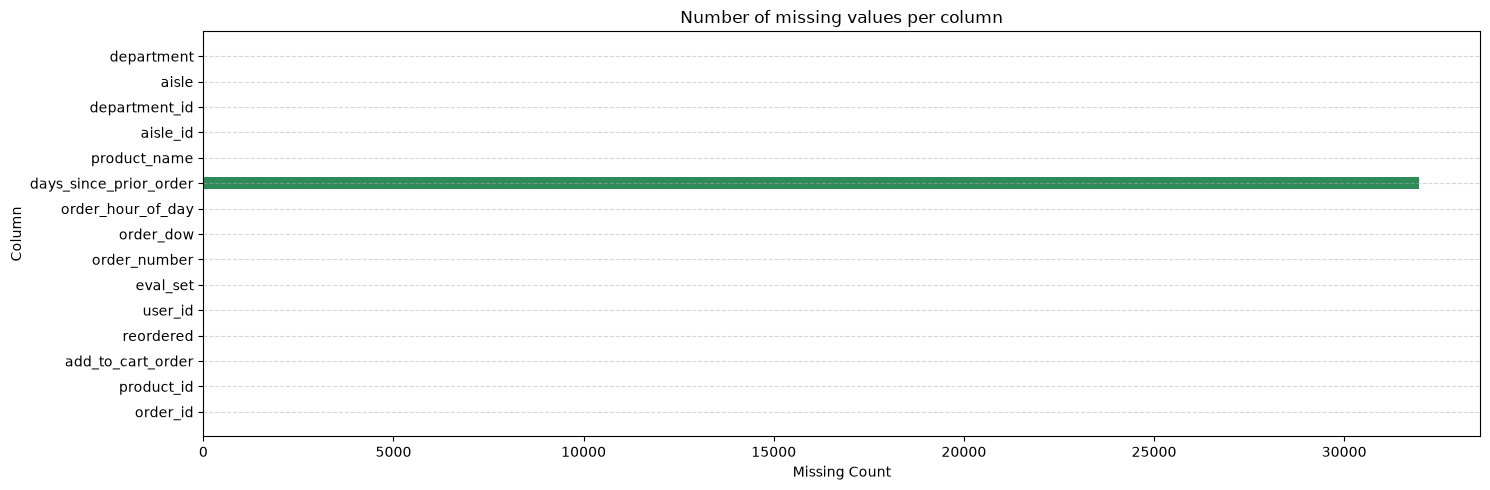

In [31]:
plt.figure(figsize=(15, 5))
missing_all = df_merged.isna().sum()
plt.barh(missing_all.index, missing_all.values, color='seagreen' ,height=0.5)
plt.title('Number of missing values per column')
plt.xlabel('Missing Count',)
plt.ylabel('Column',)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [32]:
df_mergen_clean = df_merged.copy()
print('Original shape:', df_merged.shape)

Original shape: (500000, 15)


In [33]:
df_mergen_clean = df_mergen_clean.drop(columns=['days_since_prior_order'], )
print('After dropping days_since_prior_order column:', df_mergen_clean.shape)
print('Remaining columns:', list(df_mergen_clean.columns))

After dropping days_since_prior_order column: (500000, 14)
Remaining columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department']


# 4. Data Visualization & Insights

In this section, we will explore the merged and cleaned dataset visually to uncover key consumer behavior trends and top-selling categories.




## 4.1 Top 10 Selling Departments
We analyze the departments with the highest volume of orders to see which product categories drive the most sales.

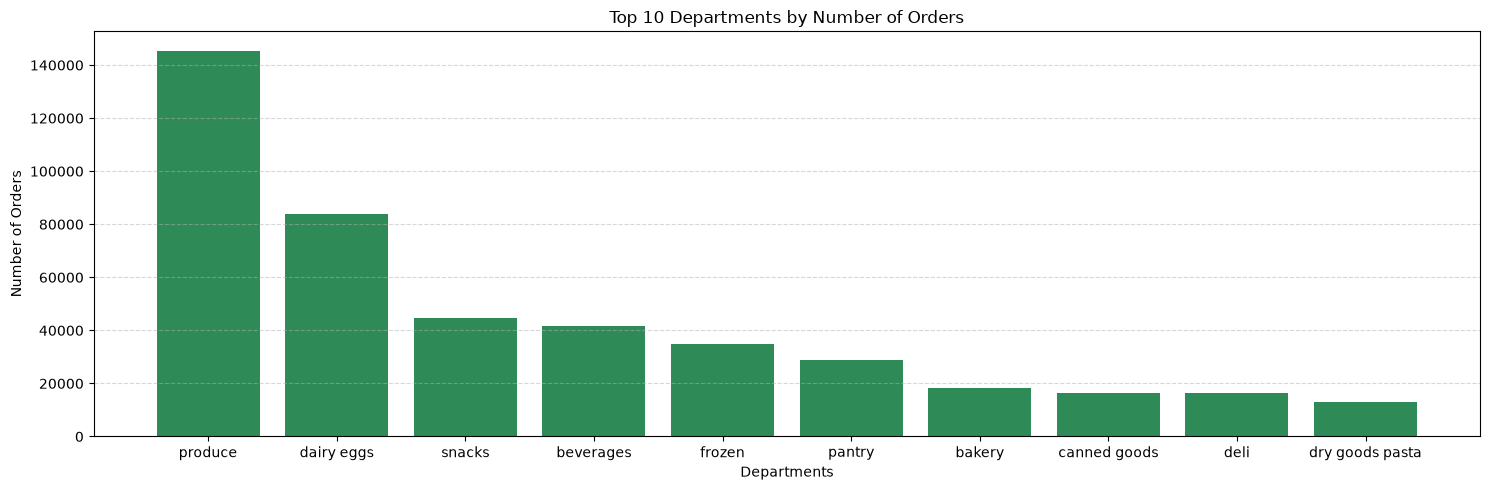

In [34]:
top_departments = df_merged['department'].value_counts().head(10)
plt.figure(figsize=(15, 5))
plt.bar(top_departments.index, top_departments.values, color='seagreen')
plt.title('Top 10 Departments by Number of Orders')
plt.xlabel('Departments')
plt.ylabel('Number of Orders')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4.2 Bottom 10 Least Selling Departments

We analyze the 10 departments with the lowest order volumes to identify underperforming product categories.

* **Observation:** Product categories like `other`, `bulk`, `missing`, and `pets` have the lowest demand among consumers, with some categories recording fewer than 2,000 orders in this sample.


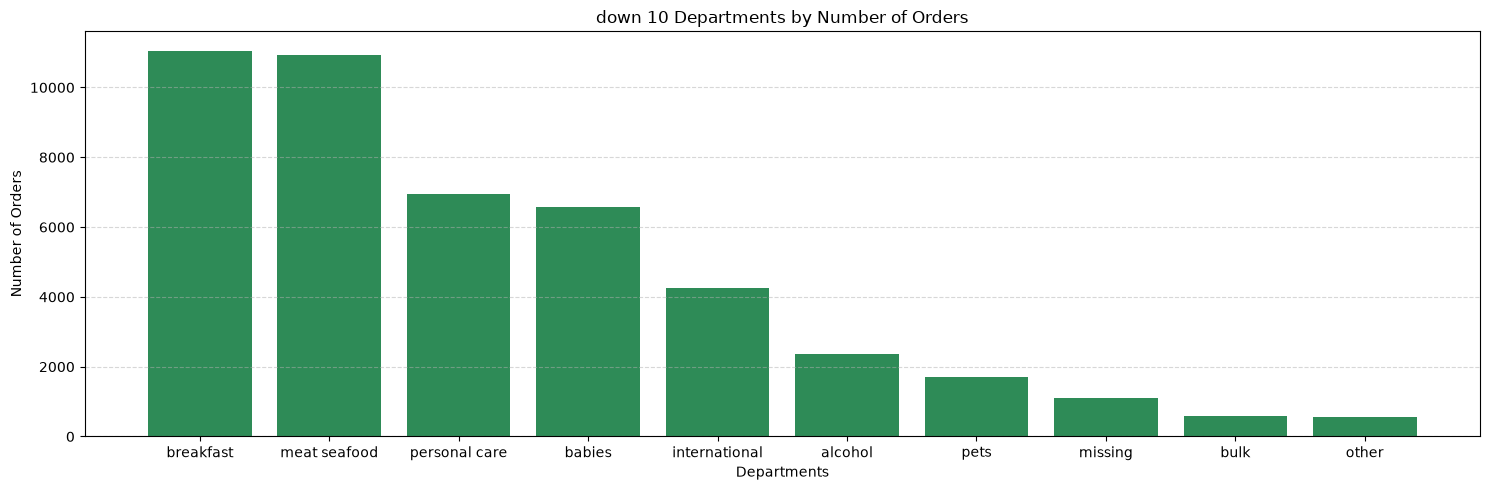

In [35]:
down_departments = df_merged['department'].value_counts().tail(10)
plt.figure(figsize=(15, 5))
plt.bar(down_departments.index, down_departments.values, color='seagreen')
plt.title('down 10 Departments by Number of Orders')
plt.xlabel('Departments')
plt.ylabel('Number of Orders')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4.3 Top 10 Best Selling Aisles

We break down the sales data further by exploring the top 10 specific product aisles to identify the most frequently purchased grocery categories.

* **Observation:** `fresh fruits` and `fresh vegetables` are leading the charts by a massive margin, both crossing 45,000 orders. This indicates that fresh produce is the primary driver of traffic for this grocery platform.


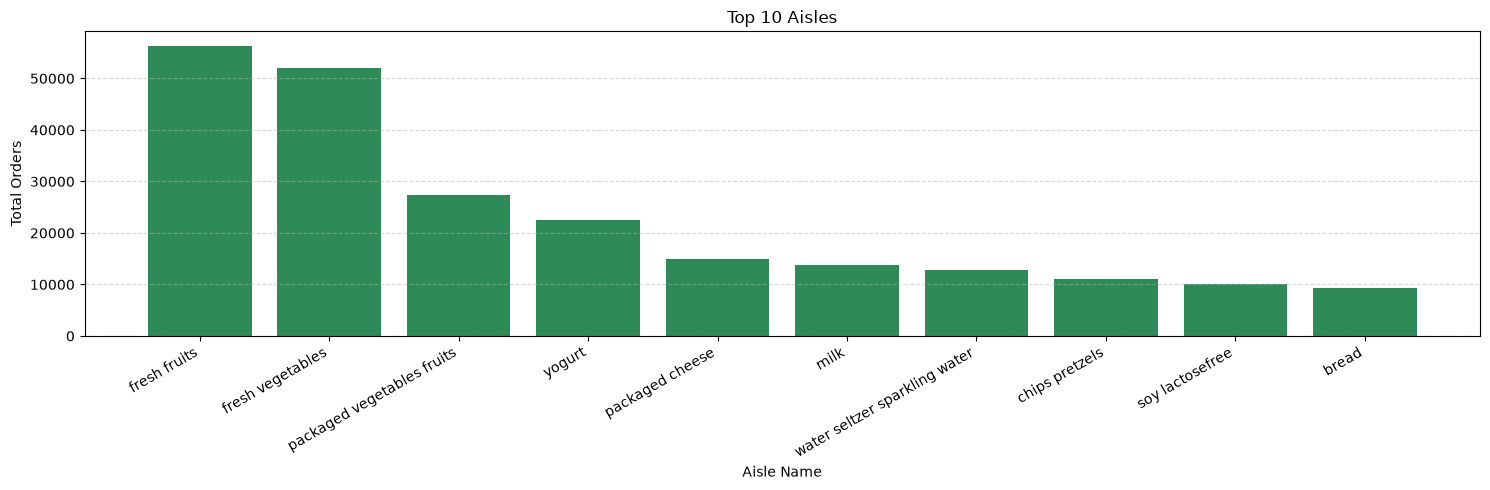

In [36]:
top_aisles = df_merged['aisle'].value_counts().head(10)
plt.figure(figsize=(15, 5))
plt.bar(top_aisles.index, top_aisles.values, color='seagreen')
plt.title('Top 10 Aisles')
plt.xlabel('Aisle Name')
plt.ylabel('Total Orders')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4.4 Customer Reorder Status Analysis

We examine the proportion of products being reordered versus those being bought for the very first time by a customer.

* **Observation:** Out of the 500,000 items in this sample, a huge portion (nearly 175,000 items) are reorders (`1`). This strong reorder rate demonstrates high customer retention and repetitive buying habits on the platform.


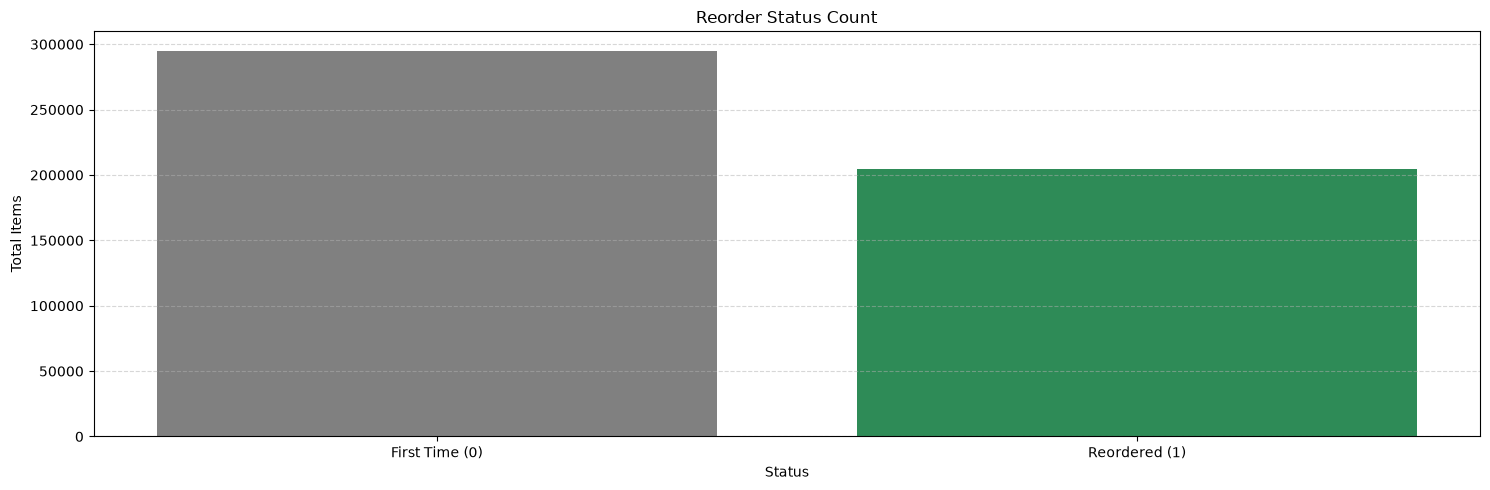

In [37]:
reorder_counts = df_merged['reordered'].value_counts()
plt.figure(figsize=(15, 5))
plt.bar(['First Time (0)', 'Reordered (1)'], reorder_counts.values, color=['gray', 'seagreen'])
plt.title('Reorder Status Count')
plt.xlabel('Status')
plt.ylabel('Total Items')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4.5 Hourly Order Distribution (Peak Times)

We analyze the distribution of orders throughout the 24 hours of the day to identify when the platform experiences its peak traffic (Most Crowded Hours).

* **Observation:** The plot reveals a clear bell curve distribution. Orders start climbing sharply from 7:00 AM, peaking between **10:00 AM and 4:00 PM** (reaching around 35,000+ orders per hour). Traffic then steadily declines into the late evening and night.


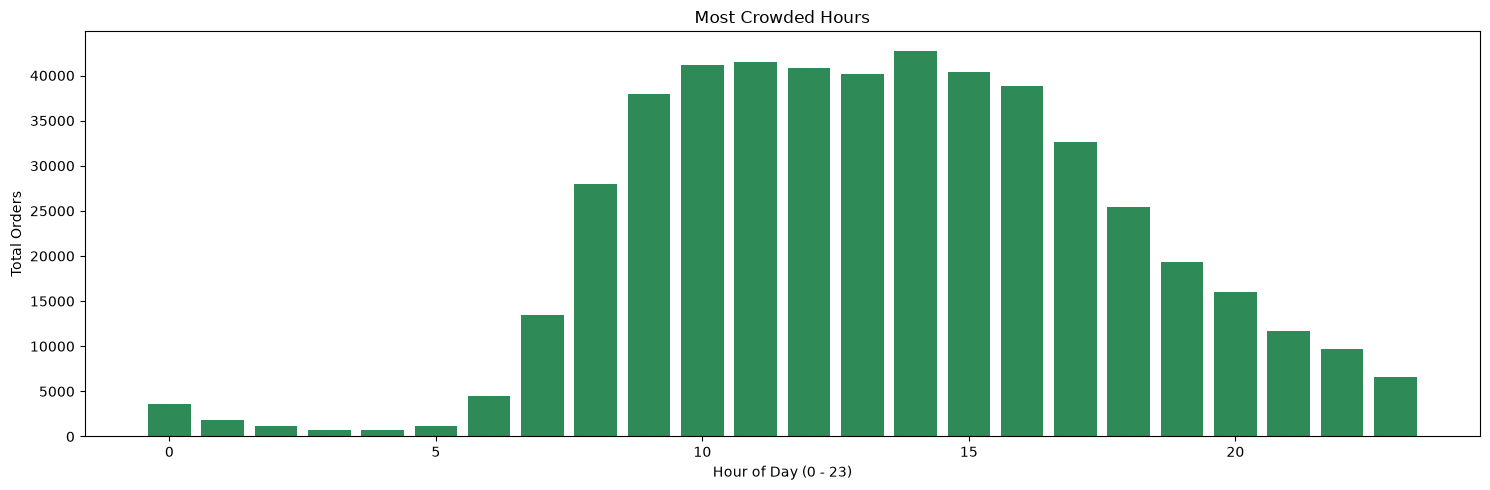

In [38]:
hourly_counts = df_merged['order_hour_of_day'].value_counts().sort_index()
plt.figure(figsize=(15, 5))
plt.bar(hourly_counts.index, hourly_counts.values, color='seagreen')
plt.title('Most Crowded Hours')
plt.xlabel('Hour of Day (0 - 23)')
plt.ylabel('Total Orders')

plt.tight_layout()
plt.show()

## 4.6 Distribution of Orders per User

We analyze how many times an individual customer places an order on the platform to understand purchasing frequency and customer engagement.

* **Observation:** The vast majority of users in this sample (around 30,000 users) have placed **only 1 order**. There is a sharp decline for users placing 2 or 3 orders. This indicates a high number of one-time trial users, suggesting the business needs to focus on strategies to encourage second-time purchases.


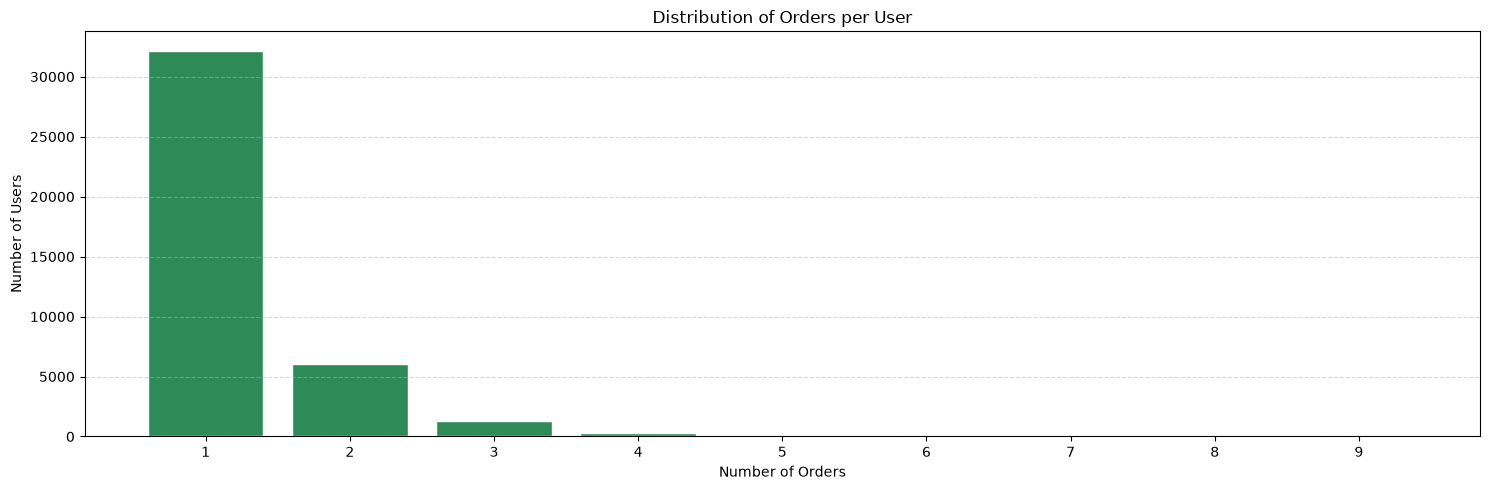

In [39]:
orders_per_user = df_merged.groupby('user_id')['order_id'].nunique()
plt.figure(figsize=(15, 5))
max_orders = orders_per_user.max()
bins = np.arange(0.5, max_orders + 1.5, 1)
plt.hist(orders_per_user, bins=bins, color='seagreen', edgecolor='white', rwidth=0.8)
plt.title('Distribution of Orders per User')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Users')
plt.xticks(range(1, int(max_orders) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4.7 Top 10 Most Reordered Products

We filter the dataset for reordered items (`reordered == 1`) and find the top 10 products that customers buy repeatedly.

* **Observation:** `Banana` and `Bag of Organic Bananas` are the absolute top reordered products, leading by a massive margin (crossing 5,000+ reorders). Fresh organic produce like strawberries, spinach, and avocados dominate the rest of the list, showing a strong consumer preference for healthy foods.


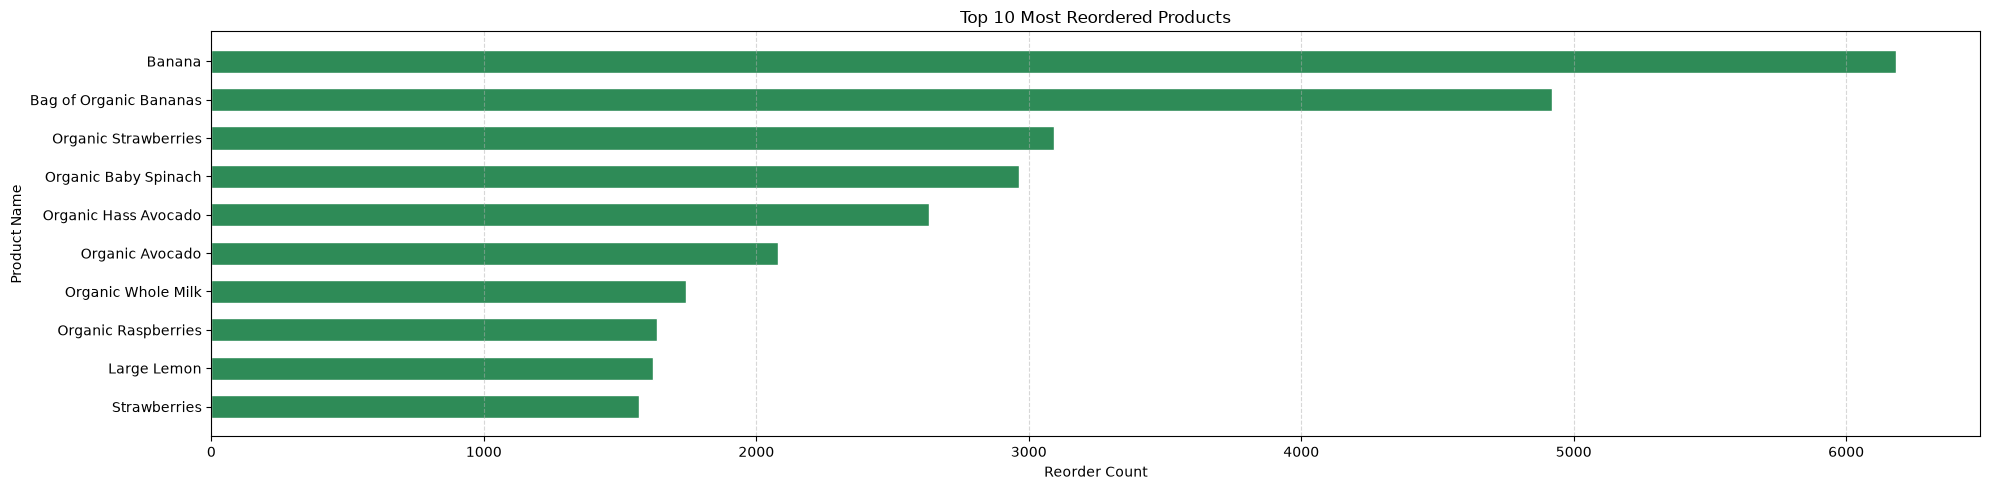

In [40]:
top_reordered = df_merged[df_merged['reordered'] == 1]['product_name'].value_counts().head(10)
plt.figure(figsize=(20, 5))
plt.barh(top_reordered.index, top_reordered.values, color='seagreen',edgecolor='white', height=0.6 )
plt.gca().invert_yaxis()
plt.title('Top 10 Most Reordered Products')
plt.xlabel('Reorder Count')
plt.ylabel('Product Name')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4.8 Reorder Rate Trend by Hour of Day

We calculate the average percentage of reordered items for each hour of the day to see when customers are most likely to repeat their routine purchases.

* **Observation:** The plot shows two fascinating peaks in customer loyalty. The absolute highest reorder rate occurs in the early morning at **6:00 AM** (>64%), followed by a secondary surge late at night around **11:00 PM** (~62%). This indicates that routine, recurring shopping behaviors mostly happen outside standard working hours.


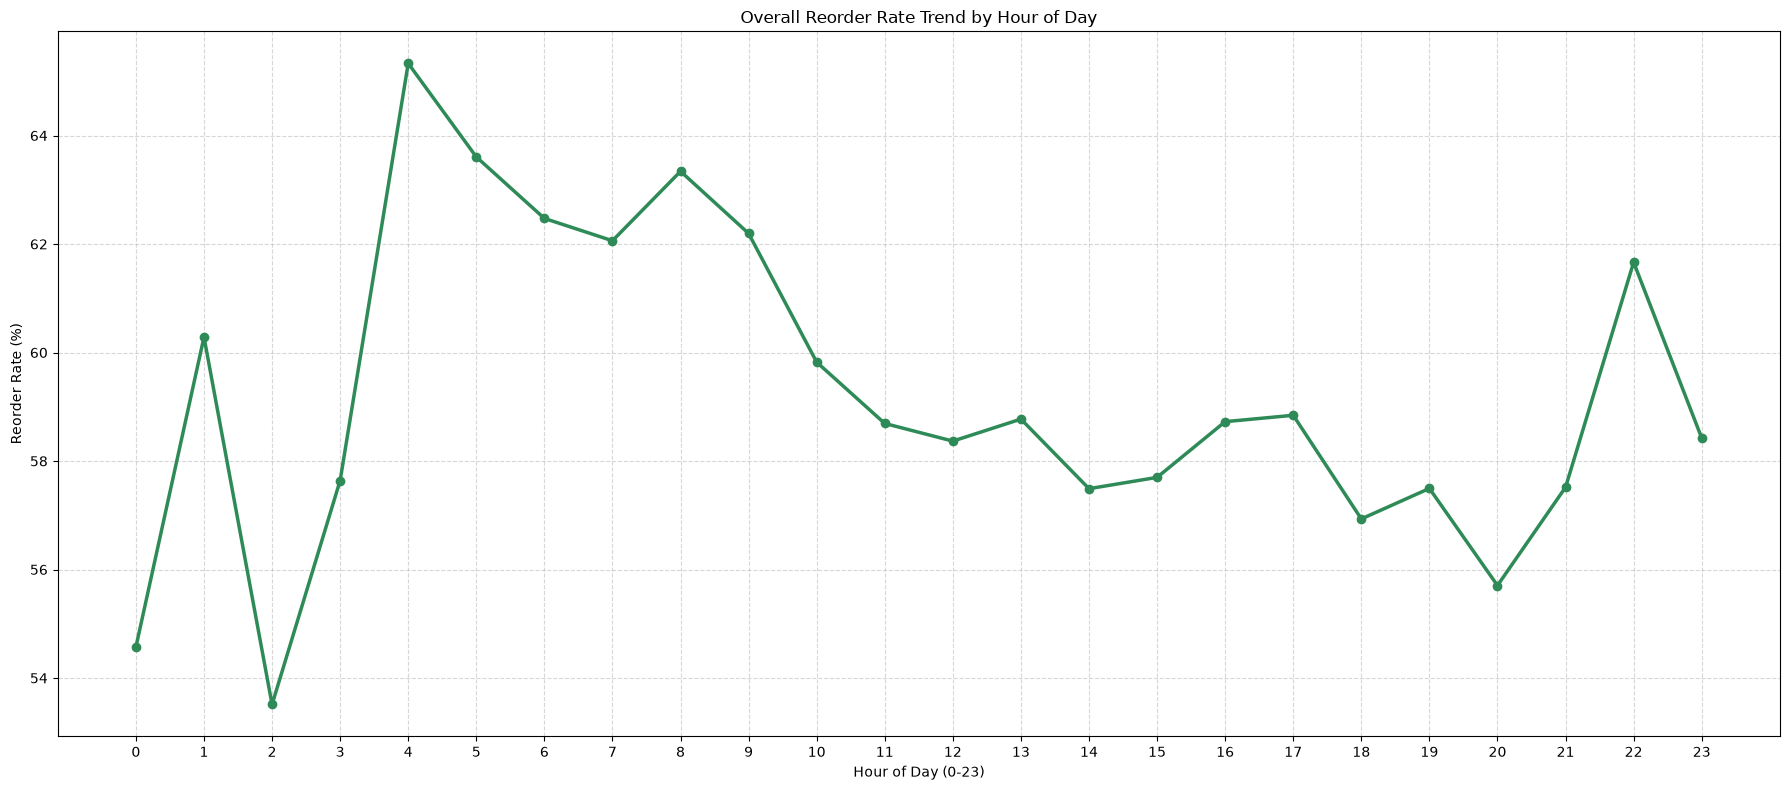

In [41]:

# # Calculate the average repurchase rate per hour out of 24 hours and convert it to a percentage
hourly_reorders = df_mergen_clean.groupby('order_hour_of_day')['reordered'].mean() * 100

plt.figure(figsize=(18, 8))

plt.plot(hourly_reorders.index, hourly_reorders.values, marker='o', color='seagreen', linewidth=2.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Overall Reorder Rate Trend by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Reorder Rate (%)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 4.9 Add-to-Cart Order Priorities

We analyze the average position or order in which the top 10 most popular products are added to the shopping cart. A lower average position means the product is added earlier during the shopping session.

* **Observation:** `Banana` and `Bag of Organic Bananas` have the lowest average add-to-cart order, meaning they are typically the very first items customers think of and add to their carts. This reflects high urgency and routine dependency on these specific items.


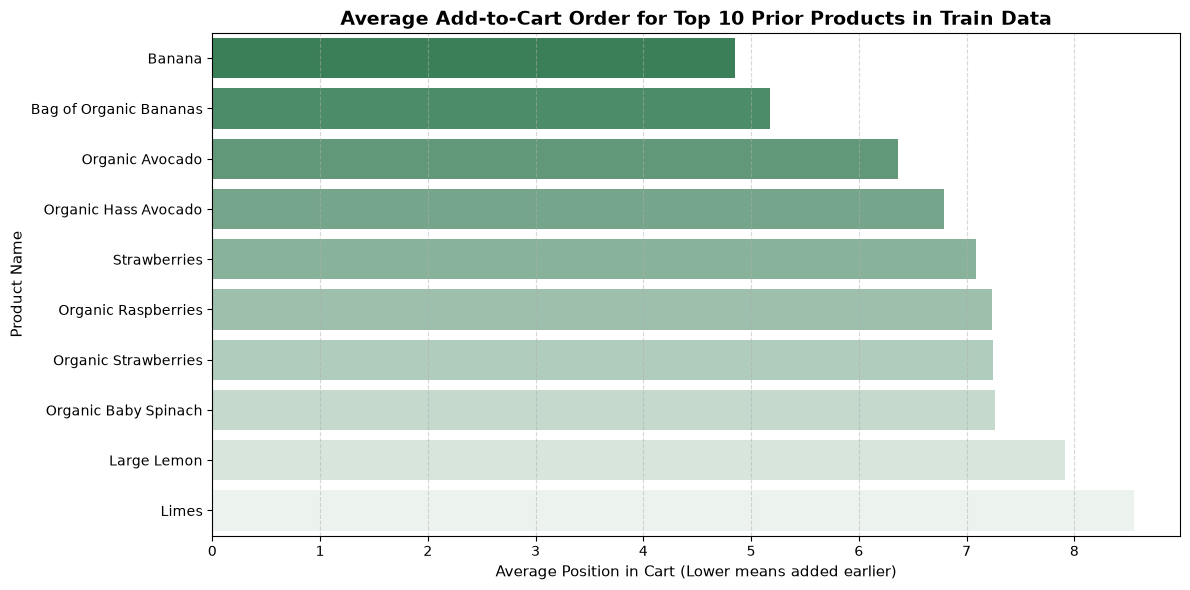

In [42]:
# Identifying the top 10 products in prior
top_10_prior_products = df_merged['product_name'].value_counts().head(10).index
train_cart_order = df_merged.groupby('product_name')['add_to_cart_order'].mean()
top_10_cart_order = train_cart_order.reindex(top_10_prior_products).dropna().sort_values()


plt.figure(figsize=(12, 6))
seagreen_palette = sns.light_palette("seagreen", n_colors=10, reverse=True)
sns.barplot(
    x=top_10_cart_order.values, 
    y=top_10_cart_order.index, 
    hue=top_10_cart_order.index,
    palette= seagreen_palette , 
    legend=False
)


plt.title('Average Add-to-Cart Order for Top 10 Prior Products in Train Data', fontsize=14, fontweight='bold')
plt.xlabel('Average Position in Cart (Lower means added earlier)', fontsize=11)
plt.ylabel('Product Name', fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4.10 Cart Size Evolution (Prior vs. Last Order)

We calculate the total number of products per cart for each customer and compare the average cart size between their historical orders (`Prior Orders`) and their very latest purchase (`Last Order`).

* **Observation:** This analysis helps us see if customer spending patterns are growing or shrinking over time. (Note: Look at the generated bars to see if the `Last Order` bar is taller or shorter than `Prior Orders` to evaluate customer lifetime value trend).


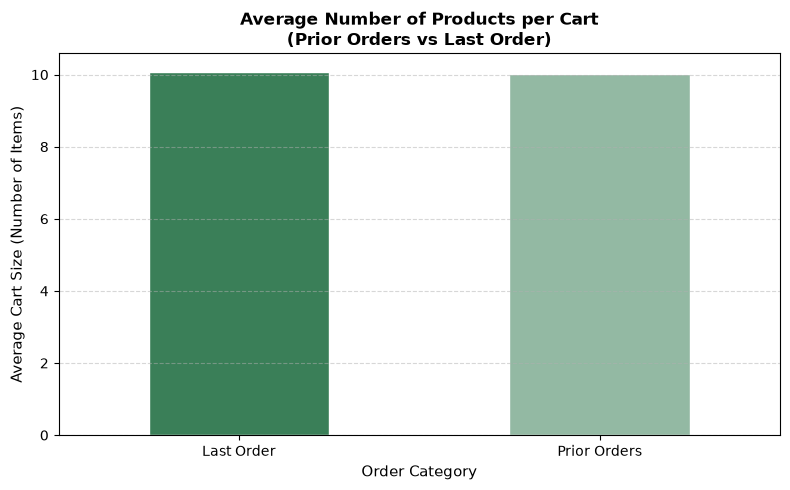

In [43]:

# Calculate cart size for each order
cart_sizes = df_merged.groupby(['user_id', 'order_id', 'order_number'])['product_id'].count().reset_index()

max_orders = cart_sizes.groupby('user_id')['order_number'].transform('max')
cart_sizes['Order_Category'] = 'Prior Orders'
cart_sizes.loc[cart_sizes['order_number'] == max_orders, 'Order_Category'] = 'Last Order'

# Calculating Averages
avg_cart_size = cart_sizes.groupby('Order_Category')['product_id'].mean().reset_index()

plt.figure(figsize=(8, 5))
seagreen_palette = sns.light_palette("seagreen", n_colors=3, reverse=True)[0:2]

sns.barplot(
    data=avg_cart_size, 
    x='Order_Category', 
    y='product_id', 
    hue='Order_Category',
    palette=seagreen_palette,
    legend=False,
    edgecolor='white',
    width=0.5
)

plt.title('Average Number of Products per Cart\n(Prior Orders vs Last Order)', fontsize=12, fontweight='bold')
plt.xlabel('Order Category', fontsize=11)
plt.ylabel('Average Cart Size (Number of Items)', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 4.11 Department Sales Volume Share (%)

We calculate the exact percentage share of total sales contributed by each department to evaluate their relative importance to the business.

* **Observation:** This visualization provides a clear overview of the store's primary revenue drivers. It highlights which top 5 categories dominate the total sales percentage, while identifying the lowest-performing departments that may need promotional strategies.


Top 5 best-selling categories in the store :
- Department[produce]: Represent 29.09% of total sales
- Department[dairy eggs]: Represent 16.76% of total sales
- Department[snacks]: Represent 8.90% of total sales
- Department[beverages]: Represent 8.32% of total sales
- Department[frozen]: Represent 6.95% of total sales
The 5 lowest-selling categories in the store:
- Departments[alcohol]:Represent 0.47% of total sales
- Departments[pets]:Represent 0.34% of total sales
- Departments[missing]:Represent 0.22% of total sales
- Departments[bulk]:Represent 0.12% of total sales
- Departments[other]:Represent 0.11% of total sales


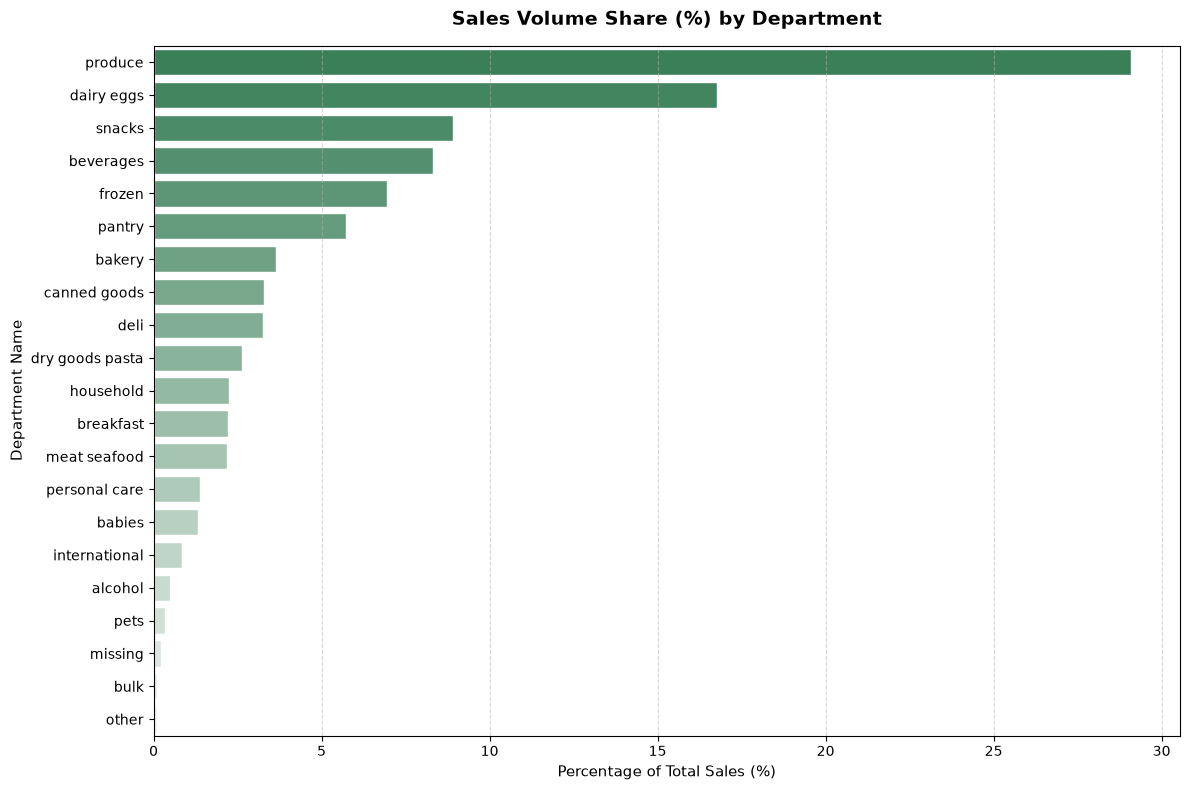

In [44]:


#Calculate the sales volume for each department and its percentage of the total store sales
dept_sales = df_merged['department'].value_counts()
dept_sales_pct = (dept_sales / dept_sales.sum()) * 100
dept_sales_pct = dept_sales_pct.sort_values(ascending=False)

print ("Top 5 best-selling categories in the store :")
print("="*40)
for dept, pct in dept_sales_pct.head(5).items():
    print(f"- Department[{dept}]: Represent {pct:.2f}% of total sales")


print("="*40)
print("The 5 lowest-selling categories in the store:")
print("="*40)
for dept, pct in dept_sales_pct.tail(5).items():
    print(f"- Departments[{dept}]:Represent {pct:.2f}% of total sales")
plt.figure(figsize=(12, 8))


seagreen_palette = sns.light_palette("seagreen", n_colors=len(dept_sales_pct), reverse=True)

sns.barplot(
    x=dept_sales_pct.values, 
    y=dept_sales_pct.index, 
    hue=dept_sales_pct.index,
    palette=seagreen_palette,
    legend=False,
    edgecolor='white'
)


plt.title('Sales Volume Share (%) by Department', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Percentage of Total Sales (%)', fontsize=11)
plt.ylabel('Department Name', fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 4.12 Distribution of Days Between Customer Orders

We analyze the time gap (in days) between consecutive customer purchases to understand shopping frequency and intervals.

* **Observation:** The histogram will show a massive spike exactly at **30 days** (and a smaller one at **7 days**). This indicates that a huge portion of users shop on a strict monthly routine, while another segment operates on a weekly grocery cycle.


Average number of days between each order 11.0 day
Median of days (most frequently occurring value) 8.0 day


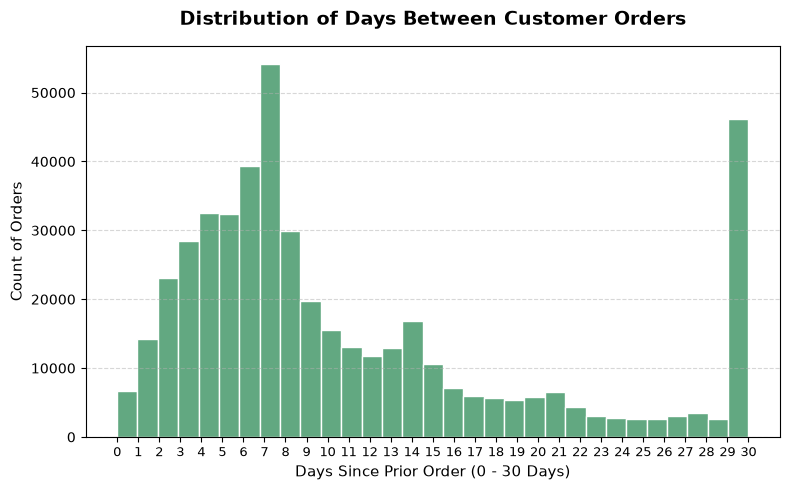

In [45]:


# I will extract the column of days since the previous request and delete the missing values.
days_since_prior = df_merged['days_since_prior_order'].dropna()                                                                                                                                                                                                                                                                                                                                                                                              

# Calculating the average and median to understand purchasing methods
avg_days = days_since_prior.mean()
median_days = days_since_prior.median()

print("="*40)
print(f"Average number of days between each order {avg_days:.1f} day")
print(f"Median of days (most frequently occurring value) {median_days:.1f} day")
print("="*40)

plt.figure(figsize=(8, 5))

sns.histplot(
    days_since_prior, 
    bins=31, 
    kde=False, 
    color='seagreen', 
    edgecolor='white'
)

plt.title('Distribution of Days Between Customer Orders', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Days Since Prior Order (0 - 30 Days)', fontsize=11)
plt.ylabel('Count of Orders', fontsize=11)

plt.xticks(range(0, 31, 1), rotation=0, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# 5. Predictive Modeling (Machine Learning)

In this final phase, we built a Predictive Model using **RandomForestRegressor** to predict the number of days until a customer's next order (`days_since_prior_order`) based on features like the hour of the day and the day of the week.

### Model Evaluation:
* **Algorithm:** Random Forest Regressor
* **Mean Absolute Error (MAE):** 6.92 days
* **Conclusion:** On average, the model's predictions deviate by about 7 days from the actual ordering behavior. This baseline model demonstrates how historical shopping frequencies can be leveraged to anticipate customer demand.


In [46]:


# 1. Feature Selection & Target Definition
df_merged = df_merged.dropna(subset=['order_hour_of_day','order_dow','days_since_prior_order'])
X = df_merged[['order_hour_of_day', 'order_dow']]# اFeatures
y = df_merged['days_since_prior_order']      

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Initialization & Training
ai_model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
ai_model.fit(X_train, y_train)

# 4. Model Evaluation (MAE)
predictions = ai_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print("--- AI Model Successfully Trained! ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} days")

--- AI Model Successfully Trained! ---
Mean Absolute Error (MAE): 6.92 days
